<a href="https://colab.research.google.com/github/AFreeSeagul/IC-GSS-Python/blob/main/Experiments_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![banner](https://github.com/ImperialCollegeLondon/physics-summer-school/blob/main/notebooks/images/ImperialBanner_trans.png?raw=1)

# 1. Experiment 1

Investigation of the mass dependence of a pendulum's oscillation period.

For this experiment we require you to make the most precise measurements possible. To this end We recommend that you record multiple swings and repeat for each mass.

First we will import the module that will allow use to create a spreadsheet that we can use to record our data.

## 1.1 Setting up data collection environment.

Firstly, if (and *ONLY* if) we are running on Google Colab, we need to enable widgets by running the following code block.

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

Next we will need to install the required `physics_summer_school` package by running the next code cell.

In [3]:
%pip install git+https://github.com/alexanderrichards/physics_summer_school.git

  Cloning https://github.com/alexanderrichards/physics_summer_school.git to /tmp/pip-req-build-vyvw6u23
  Running command git clone --filter=blob:none --quiet https://github.com/alexanderrichards/physics_summer_school.git /tmp/pip-req-build-vyvw6u23
  Resolved https://github.com/alexanderrichards/physics_summer_school.git to commit 4ce96e232f1c1cc31eaf7b5d004c6bba622a8015
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.6 MB/s eta 0:00:00
  Created wheel for physics_summer_school: filename=physics_summer_school-0.1.0-py3-none-any.whl size=2667 sha256=61e2d13d09ae16b51bcf2166c444f87970b787b20f36a05e4ad29b24fd2057b7
  Stored in directory: /tmp/pip-ephem-wheel-cache-jeo86_j9/wheels/7d/3c/67/edf4ce096cc925e470643de68d25353aa255074ed5df78d6a8
Successfully built physics_sum

Finally, we will import the packages we will need in this notebook.

In [4]:
import numpy as np
import scipy.stats as sps
import scipy.optimize as spo
import matplotlib.pyplot as plt
import physics_summer_school as pss

 Now let's create our spreadsheet using the `pss.sheet_exp1()` function (see below). Note that this function takes two parameters:
 * `n_masses`: This is the number of masses that you intend to measure the period for.
 * `n_repeats`: How many times you will repeat the measurement

 You are free to change these numbers to suit how you will do your experiment however you will be required to do at least 3 masses.

In [ ]:
#1st
#length of the string = 41cm
#angle = 10deg
#mass in g
#time 10 periods to calculate time taken for each period

#2nd
#length of the string = 41cm
#angle = 10deg
#mass in g
#time 10 periods to calculate time taken for each period

#3rd
#length of the string = 41cm
#angle = 10deg
#mass in g
#time 10 periods to calculate time taken for each period

In [11]:
sheet1 = pss.sheet_exp1(n_masses=4, n_repeats=3)
sheet1

Sheet(cells=(Cell(column_end=0, column_start=0, row_end=0, row_start=0, type='numeric', value=0.0), Cell(colum…

Support for third party widgets will remain active for the duration of the session. To disable support:

In [13]:
from google.colab import output
output.disable_custom_widget_manager()

In [14]:
data1 = sheet1.to_array()
print(data1)

mass = data1[:, 0]
T_readings = data1[:, 1:5]

T_readings[T_readings == 18.310] = np.nan
T_readings[T_readings == 11.250] = np.nan

T_avg = np.nanmean(T_readings, axis = 1)
period = T_avg / 10 #single period

print(f"Average time: {T_avg}")
print(f"Time for one period: {period}")

#data 18.310 and 11.250 are anomalous, which are ignored

#ignoring the outliers, the average comes out as 12.71(2) and 12.73(3)

[[43.72 12.59 12.63 12.33 12.44]
 [48.72 18.31 12.63 12.69 12.81]
 [53.72 12.75 12.78 12.66 11.25]
 [38.72 12.15 12.5  12.47  0.  ]]
Average time: [12.4975 12.71   12.73    9.28  ]
Time for one period: [1.24975 1.271   1.273   0.928  ]


Original data:
[[43.72 12.59 12.63 12.33 12.44]
 [48.72 18.31 12.63 12.69 12.81]
 [53.72 12.75 12.78 12.66 11.25]
 [38.72 12.15 12.5  12.47 12.4 ]]

Mass:
[43.72 48.72 53.72 38.72]

Single-period readings:
[[1.259 1.263 1.233 1.244]
 [  nan 1.263 1.269 1.281]
 [1.275 1.278 1.266   nan]
 [1.215 1.25  1.247 1.24 ]]

Average period:
[1.24975 1.271   1.273   1.238  ]

Standard deviation:
[0.01384136 0.00916515 0.006245   0.01589549]


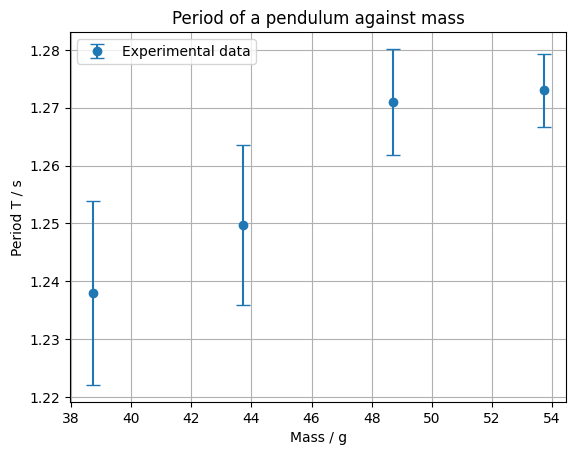

In [27]:
# Plotting the graph
import numpy as np
import matplotlib.pyplot as plt

data1 = sheet1.to_array()

print("Original data:")
print(data1)

mass = data1[:, 0]

time_10_periods = data1[:, 1:5]

valid_rows = mass != 0

mass = mass[valid_rows]
time_10_periods = time_10_periods[valid_rows]

time_10_periods[np.isclose(time_10_periods, 18.310)] = np.nan
time_10_periods[np.isclose(time_10_periods, 11.250)] = np.nan

period_readings = time_10_periods / 10

period_avg = np.nanmean(period_readings, axis=1)

period_std = np.nanstd(period_readings, axis=1, ddof=1)

print("\nMass:", mass)

print("\nSingle-period readings:", period_readings)

print("\nAverage period:", period_avg)

print("\nStandard deviation:", period_std)

# Plot the graph
plt.errorbar(
    mass,
    period_avg,
    yerr=period_std,
    fmt="o",
    capsize=5,
    label="Experimental data"
)

plt.xlabel("Mass / g")
plt.ylabel("Period T / s")
plt.title("Period of a pendulum against mass")

plt.grid()
plt.legend()
plt.show()

## 1.2 Conduct the experiment

Now you should go ahead and conduct the experiment. Remember to try and make the most precise measurements that you can. You are free to approach the experiment however you wish and you are encouraged to innovate as necessary.

**remember to input your measured values directly into the cells of the spreadsheet above. Note that you will need to either click off a cell (or press enter) after putting in your value for it to be properly updated.**

Once you are done, the next step is to save the date to a persistent storage medium like the your USB stick. Do this by using the `save()` method of your sheet.

In [28]:
sheet1.save()

## 1.3 Data analysis

The first step will be to load the data we just saved. Note, we could just use sheet1 from above however if we were to exit this notebook and load it again sheet1 would be empty just as it was when you started today. For this reason we will recreate it from the data we saved using `pss.load_exp1()`.

In [34]:
sheet1 = pss.load_exp1()
sheet1

Sheet(cells=(Cell(column_start=0, row_start=0, squeeze_column=False, squeeze_row=False, type='numeric', value=…

Support for third party widgets will remain active for the duration of the session. To disable support:

In [30]:
from google.colab import output
output.disable_custom_widget_manager()

Now it is time to get the data into a format that we can work with, like numpy. To do this you can use the `to_array()` method.

In [32]:
data1 = sheet1.to_array()
data1

array([[43.72, 12.59, 12.63, 12.33, 12.44],
       [48.72, 18.31, 12.63, 12.69, 12.81],
       [53.72, 12.75, 12.78, 12.66, 11.25],
       [38.72, 12.15, 12.5 , 12.47, 12.4 ]])

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()

### 1.3.1 Plotting you data

Now we are going to plot your data using matplotlib. Your plot should have the following:
* data points **with error bars**
* both x and y labels **with units**
* title

Original data:
[[43.72 12.59 12.63 12.33 12.44]
 [48.72 18.31 12.63 12.69 12.81]
 [53.72 12.75 12.78 12.66 11.25]
 [38.72 12.15 12.5  12.47 12.4 ]]

Mass: [43.72 48.72 53.72 38.72]

Single-period readings: [[1.259 1.263 1.233 1.244]
 [  nan 1.263 1.269 1.281]
 [1.275 1.278 1.266   nan]
 [1.215 1.25  1.247 1.24 ]]

Average period: [1.24975 1.271   1.273   1.238  ]

Standard deviation: [0.01384136 0.00916515 0.006245   0.01589549]


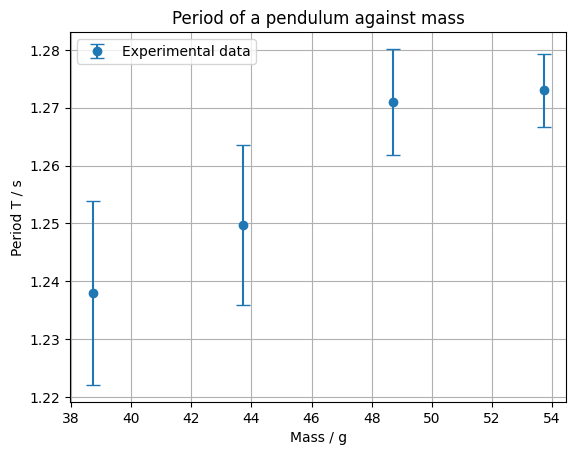

In [35]:
# Plotting the graph
import numpy as np
import matplotlib.pyplot as plt

data1 = sheet1.to_array()

print("Original data:")
print(data1)

mass = data1[:, 0]

time_10_periods = data1[:, 1:5]

valid_rows = mass != 0

mass = mass[valid_rows]
time_10_periods = time_10_periods[valid_rows]

time_10_periods[np.isclose(time_10_periods, 18.310)] = np.nan
time_10_periods[np.isclose(time_10_periods, 11.250)] = np.nan

period_readings = time_10_periods / 10

period_avg = np.nanmean(period_readings, axis=1)

period_std = np.nanstd(period_readings, axis=1, ddof=1)

print("\nMass:", mass)

print("\nSingle-period readings:", period_readings)

print("\nAverage period:", period_avg)

print("\nStandard deviation:", period_std)

# Plot the graph
plt.errorbar(
    mass,
    period_avg,
    yerr=period_std,
    fmt="o",
    capsize=5,
    label="Experimental data"
)

plt.xlabel("Mass / g")
plt.ylabel("Period T / s")
plt.title("Period of a pendulum against mass")

plt.grid()
plt.legend()
plt.show()

### 1.3.2 Fitting your data

Now that we have our data points plotted, let's try and fit them. Before this can be done, we should be able to answre the following:
* What would be the correct function to fit this data?
* What do the parameters of the fit signify?
* what values of these parameters do we expect (should use as a starting point) from the lecture material?

With the answers to the above in mind, we can use the [`spo.curve_fit()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) function which you learnt about this morning to fit your data.

The parameters
[0.00218866 1.15736755]
The covariance matrix
[[ 3.71074817e-07 -1.85753689e-05]
 [-1.85753689e-05  9.38457140e-04]]
So the values with errors are:
a=  0.0021886637902125234  +/-  0.0006091591065664571
c=  1.1573675530142304  +/-  0.03063424782367447


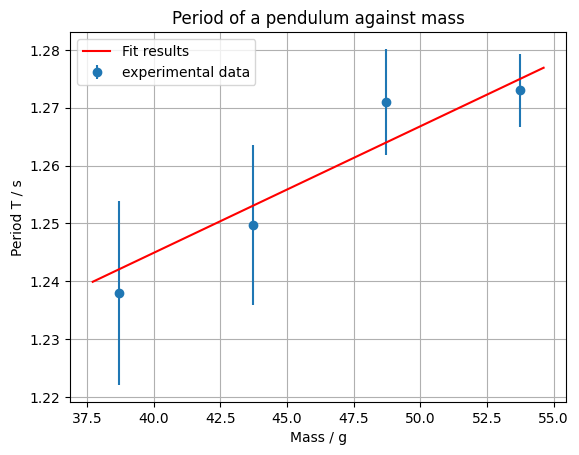

In [38]:
from IPython.core.compilerop import time
import numpy as np
import scipy.optimize as spo
import matplotlib.pyplot as plt

data1 = sheet1.to_array()
mass = data1[:, 0]
time_10_periods = data1[:, 1:5]
valid_rows = mass != 0
mass = mass[valid_rows]
time_10_periods = time_10_periods[valid_rows]
time_10_periods[1, 0] = np.nan
time_10_periods[2, 3] = np.nan

period_readings = time_10_periods / 10
period_avg = np.nanmean(period_readings, axis = 1)
period_std = np.nanstd(period_readings, axis = 1, ddof = 1)

x = mass
y = period_avg
y_err = period_std

#defint the best-fit function
def fit_func(x, m, c):
  return m * x + c

initial_guess = [0, 1.25]
#fit the data
po, po_cov = spo.curve_fit(fit_func, x, y, initial_guess, y_err)

print("The parameters")
print(po)
print('The covariance matrix')
print(po_cov)
print("So the values with errors are:")
print("a= ",po[0]," +/- ",np.sqrt(po_cov[0,0]))
print("c= ",po[1]," +/- ",np.sqrt(po_cov[1,1]))

plt.errorbar(x, y, yerr = y_err, fmt = 'o', label = "experimental data")
xx = np.arange(np.min(x) - 1, np.max(x) + 1, 0.1)
plt.plot(xx, fit_func(xx, po[0], po[1]), 'r-', label = "Fit results")
plt.xlabel("Mass / g")
plt.ylabel("Period T / s")
plt.title("Period of a pendulum against mass")
plt.grid()
plt.legend()
plt.show()




With your fit complete, print our the best fit values for the parameters **along with their errors**

In [39]:
print("The parameters")
print(po)
print('The covariance matrix')
print(po_cov)
print("So the values with errors are:")
print("a= ",po[0]," +/- ",np.sqrt(po_cov[0,0]))
print("c= ",po[1]," +/- ",np.sqrt(po_cov[1,1]))

The parameters
[0.00218866 1.15736755]
The covariance matrix
[[ 3.71074817e-07 -1.85753689e-05]
 [-1.85753689e-05  9.38457140e-04]]
So the values with errors are:
a=  0.0021886637902125234  +/-  0.0006091591065664571
c=  1.1573675530142304  +/-  0.03063424782367447


Finally, plot your data along with your fit on a single canvas. **Don't forget the legend**

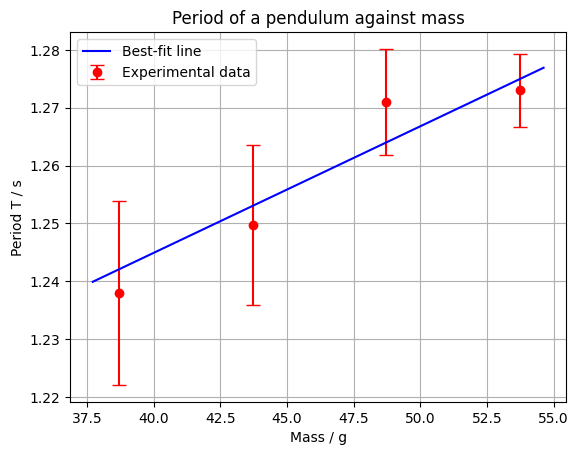

In [45]:
plt.figure(1)

plt.errorbar(x, y, yerr = y_err, fmt="ro", capsize = 5, label = "Experimental data")
xx = np.arange(np.min(x) - 1, np.max(x) + 1, 0.1)
plt.plot(xx, fit_func(xx, po[0], po[1]), "b-", label="Best-fit line")

plt.xlabel("Mass / g")
plt.ylabel("Period T / s")
plt.title("Period of a pendulum against mass")

plt.grid()
plt.legend()
plt.show()

---
# 2. Experiment 2

This experiment will have you try to determine the best value possible for the acceleration due to gravity `g`.

As before we require you to make as precise measurements as you can. We will not be measuring `g` directly but
rather extracting it from a fit to your data.

## 2.1 Setting up the environment

Let's create our spreadsheet using the `pss.sheet_exp2()` function (see below). Note that this function takes two parameters:
 * `n_lengths`: This is the number of lengths that you intend to measure the period for.
 * `n_repeats`: How many times you will repeat the measurement

You are free to change these numbers to suit how you will do your experiment however you will be required to do at least 3 lengths.

In [ ]:
sheet2 = pss.sheet_exp2(n_lengths=4, n_repeats=4)
sheet2

## 2.2 Conduct the experiment

Now you should go ahead and conduct the experiment. Remember to try and make the most precise measurements that you can. You are free to approach the experiment however you wish and you are encouraged to innovate as necessary.

**remember to input your measured values directly into the cells of the spreadsheet above. Note that you will need to either click off a cell (or press enter) after putting in your value for it to be properly updated.**

Once you are done, the next step is to save the date to a persistent storage medium like the your USB stick. Do this by using the `save()` method of your sheet.

In [ ]:
sheet2.save()

## 2.3 Data analysis

As before, we will start by loading the data we just saved. To do this we will use the `pss.load_exp2()` function.

In [ ]:
sheet2 = pss.load_exp2()
sheet2

and again we will get the data into a format that we can work with, like numpy using the `to_array()` method.

In [ ]:
data2 = sheet2.to_array()
data2

### 2.3.1 Plotting you data

Now we are going to plot your data using matplotlib. Your plot should have the following:
* data points **with error bars**
* both x and y labels **with units**
* title

### 2.3.2 Fitting your data

Now that we have our data points plotted, let's try and fit them. Before this can be done, we should be able to answre the following:
* What would be the correct function to fit this data? **recall from your lectures**
$$
T = 2 \pi \sqrt{\frac{L}{g}}
$$
* What do the parameters of the fit signify?
* what values of these parameters do we expect (should use as a starting point) from the lecture material?


With the answers to the above in mind, we can use the `spo.curve_fit()` function which you learnt about this morning to fit your data.

With your fit complete, print our the best fit values for the parameters **along with their errors**

Now lets plot your data along with your fit on a single canvas. **Don't forget the legend**

---
## 2.4 Damped extension

We can go one step further and realise that in the real world our pendulum is a damped oscillator. This means that the angular frequency $\omega$ undergoes
a slight modification.

$$
\omega = \sqrt{\omega_0^2 - \left(\frac{b}{2m}\right)^2}
$$

where $\gamma = \frac{b}{2m}$ (or just $b$) is the damping coefficient. We can use this along with the natural frequency $\omega_0$ from the theory to add the effects of damping into our model.

### 2.4.1 Fitting the data

We will refit the data from this experiment, this time using our updated model to include the effects of natural damping.
We will once again be using the `spo.curve_fit()` function to fit the data. This time we will allow the damping coefficient $b$ to be a
floating parameter of the fit.

With your fit complete, print our the best fit values for the parameters **along with their errors**

Now lets plot your data along with both your non-damped and damped fits on a single canvas. **Don't forget the legend**